# FRED API

The [Federal Reserve Economic Data (FRED)](https://fred.stlouisfed.org/) is maintained by the Federal Reserve Bank of St. Louis. It contains over 800,000 economic time series from dozens of sources, including:

- GDP and economic growth indicators
- Inflation measures (CPI, PCE)
- Interest rates and yield curves
- Employment and labor market data
- International economic data
- Cryptocurrency prices

## Getting Started with FRED

To use the FRED API, you need to:

1. Create a [FRED account](https://fred.stlouisfed.org)
2. Request an [API key](https://fredaccount.stlouisfed.org/apikeys)
3. Store your key securely (never hardcode it!)

Install the package:

```
pip install fredapi
```

## Set-up

In [ ]:
# Core packages
from fredapi import Fred
import os
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import datetime as dt

import matplotlib as mpl 
import matplotlib.pyplot as plt

# Include this to have plots show up in your Jupyter notebook.
%matplotlib inline 

In [2]:
# Load API keys from .env file
load_dotenv()

# Retrieve API keys
FRED_API_KEY = os.getenv('FRED_API_KEY')

# Initialize FRED API
fred = Fred(api_key=FRED_API_KEY)

## Secure API Key Storage

Here's the **wrong** way to use your API key:

```python
# DON'T DO THIS!
fred = Fred(api_key='your_api_key_here')
```

If you push this code to GitHub, your key is exposed to the world!

### Using a `.env` File (Recommended for Local Development)

A `.env` file is a simple text file that stores your API keys as key-value pairs. It lives in your project folder but is **never** committed to GitHub.

**Step 1**: Create a file called `.env` in your project's root folder (the same folder as your notebooks). You can do this in VS Code or any text editor. The file contents look like this:

```
FRED_API_KEY=your_actual_key_here
```

No quotes, no spaces around the `=`. Just the variable name and the key.

**Step 2**: Make sure `.env` is in your `.gitignore` file so it doesn't get pushed to GitHub:

```
# .gitignore
.env
```

**Step 3**: In your Python code, use `python-dotenv` to load the key:

```python
from dotenv import load_dotenv
import os

load_dotenv()  # Reads the .env file and loads variables into the environment
FRED_API_KEY = os.getenv('FRED_API_KEY')

fred = Fred(api_key=FRED_API_KEY)
```

`load_dotenv()` reads the `.env` file and makes its variables available through `os.getenv()`. This is exactly what our set-up cell above does.

```{note}
Install `python-dotenv` if you don't have it: `pip install python-dotenv`
```

### Using GitHub Secrets (Recommended for Codespaces)

If you're using GitHub Codespaces, you can store keys as **Codespace Secrets** instead of a `.env` file. These are encrypted and automatically available as environment variables inside your Codespace.

Here's how to add a secret:

1. Go to [github.com](https://github.com) and click your **profile picture** in the upper-right corner
2. Click **Settings**
3. In the left sidebar, scroll down to the **"Code, planning, and automation"** section and click **Codespaces**
4. Next to **"Codespaces secrets"**, click **New secret**
5. In the **Name** field, type your secret name (e.g., `FRED_API_KEY`)
6. In the **Value** field, paste your API key
7. Click the **Repository access** dropdown and select the repo(s) that should have access to this secret
8. Click **Add secret**

```{figure} ../images/07-secrets1.png
---
name: 07-secrets1.png
align: center
---
GitHub Codespaces secrets settings.
```

```{figure} ../images/07-secrets2.png
---
name: 07-secrets2.png
align: center
---
Adding a new secret.
```

Codespace Secrets are automatically available as environment variables, so you can access them the same way:

```python
FRED_API_KEY = os.getenv('FRED_API_KEY')
fred = Fred(api_key=FRED_API_KEY)
```

You don't need `load_dotenv()` for Codespace Secrets, but it doesn't hurt to include it -- if no `.env` file exists, it just does nothing.

### Troubleshooting GitHub Secrets

If your code can't find your API key (e.g., you get an error like `ValueError` or `None` when you try to use it), work through this checklist:

**1. Check your secret name for typos.** The name you use in `os.getenv('FRED_API_KEY')` must **exactly match** the name you entered on GitHub. Secret names are not case-sensitive on GitHub's side, but it's good practice to keep them consistent. Only letters, numbers, and underscores are allowed -- no spaces or special characters.

**2. Check the API key value itself.** When you paste your key into the **Value** field on GitHub, make sure you haven't accidentally copied extra spaces or characters before or after the key. A trailing space or newline character will silently break things.

**3. Make sure you granted repository access.** When you created the secret, you needed to select which repositories can use it. If you forgot to add your lab repo, the secret won't be available in that Codespace. Go back to **Settings > Codespaces > Codespaces secrets**, click on the secret name, and make sure your repo is listed under repository access.

**4. Stop and restart your Codespace.** Secrets are loaded when a Codespace starts up. If you added or changed a secret while your Codespace was already running, it won't pick up the change automatically. You need to **stop** the Codespace and then reopen it. Here's how:

   1. **Save your work first.** Do a `git add`, `git commit`, and `git push` (or use the Source Control panel in VS Code to sync) so your files are backed up to GitHub.
   2. **Close the Codespace browser tab** (or VS Code window). Note that closing the tab alone does **not** stop the Codespace -- it keeps running in the background.
   3. Go to [github.com/codespaces](https://github.com/codespaces). This page lists all of your Codespaces.
   4. Find the Codespace you want to restart. Click the **three dots** (`...`) to the right of it.
   5. Click **Stop codespace**.
   6. Once it has stopped, go back to your lab repository on GitHub and click the green **Code** button, then **Codespaces**, and open your existing Codespace. It will restart with the updated secrets.

**5. Verify the secret is loaded.** You can add a quick check in your notebook to make sure the key was found (without printing the actual key!):

```python
FRED_API_KEY = os.getenv('FRED_API_KEY')
print(type(FRED_API_KEY))  # Should print <class 'str'>, not <class 'NoneType'>
```

If it prints `<class 'NoneType'>`, the secret isn't being found. Go back through the steps above.

## FRED Example: Bitcoin Data

Let's pull Bitcoin price data from FRED. You can find the series [here](https://fred.stlouisfed.org/series/CBBTCUSD). 

When you find data on FRED, note the **series code** - that's how you'll request it via the API.

In [3]:
btc = fred.get_series('CBBTCUSD')
btc.tail()

2026-01-23    89365.99
2026-01-24    89155.13
2026-01-25    86978.89
2026-01-26    88136.48
2026-01-27    89296.00
dtype: float64

That's just a plain **Series**, not a DataFrame. Let's convert it and clean it up.

In [4]:
btc = btc.to_frame(name='btc')
btc = btc.rename_axis('date')
btc

,btc
date,
2014-12-01,370.00
2014-12-02,378.00
2014-12-03,378.00
2014-12-04,377.10
2014-12-05,NaN
...,...
2026-01-23,89365.99
2026-01-24,89155.13
2026-01-25,86978.89


In [5]:
# Drop missing values
btc = btc.dropna()

In [6]:
# Calculate returns
btc['ret'] = btc['btc'].pct_change()

/var/folders/kx/y8vj3n6n5kq_d74vj24jsnh40000gn/T/ipykernel_84807/1503532820.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btc['ret'] = btc['btc'].pct_change()


<Axes: xlabel='date'>

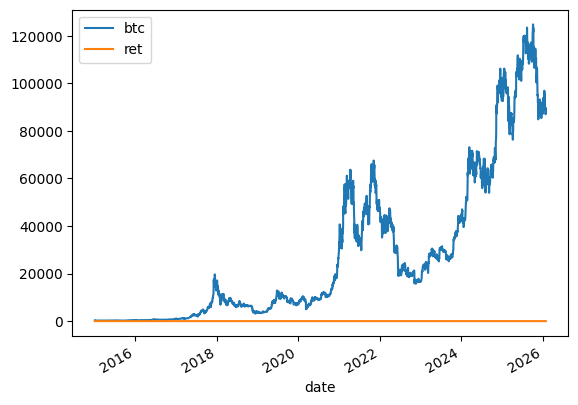

In [7]:
btc = btc.loc['2015-01-01':, ['btc', 'ret']]
btc.plot()

That's not a very good graph - the returns and price levels are in different units. Let's format the average return nicely:

In [8]:
print(f'Average return: {100 * btc.ret.mean():.2f}%')

Average return: 0.21%


## Visualizing Cumulative Returns

Let's create a cumulative return chart and daily return chart, stacked on top of each other.

In [9]:
btc['ret_g'] = btc.ret.add(1)  # gross return
btc['ret_c'] = btc.ret_g.cumprod().sub(1)  # cumulative return
btc

,btc,ret,ret_g,ret_c
date,,,,
2015-01-08,288.99,-0.150029,0.849971,-0.150029
2015-01-13,260.00,-0.100315,0.899685,-0.235294
2015-01-14,120.00,-0.538462,0.461538,-0.647059
2015-01-15,204.22,0.701833,1.701833,-0.399353
2015-01-16,199.46,-0.023308,0.976692,-0.413353
...,...,...,...,...
2026-01-23,89365.99,-0.001746,0.998254,261.841147
2026-01-24,89155.13,-0.002360,0.997640,261.220971
2026-01-25,86978.89,-0.024410,0.975590,254.820265


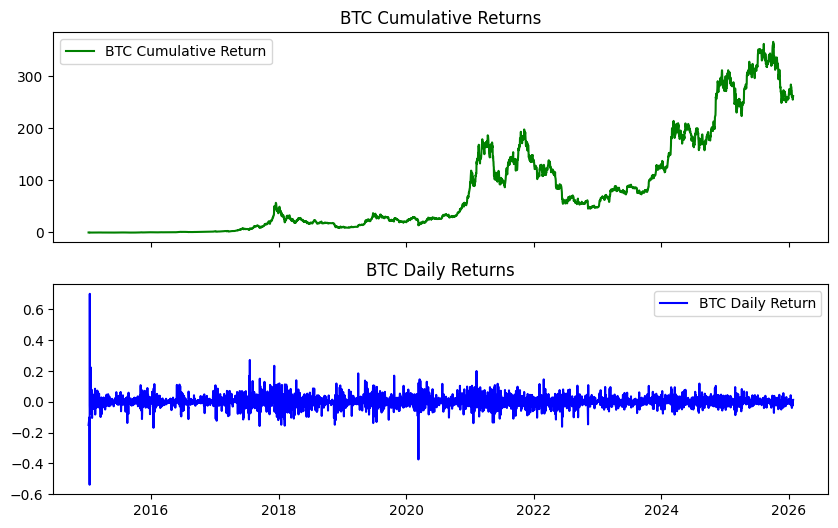

In [10]:
fig, axs = plt.subplots(2, 1, sharex=True, sharey=False, figsize=(10, 6))

axs[0].plot(btc.ret_c, 'g', label='BTC Cumulative Return')
axs[1].plot(btc.ret, 'b', label='BTC Daily Return')
            
axs[0].set_title('BTC Cumulative Returns')
axs[1].set_title('BTC Daily Returns')

axs[0].legend()
axs[1].legend();

## A Bitcoin Simulation <a id='btc-sim'></a>

Let's put together some ideas, write a function, and run a simulation using **Geometric Brownian Motion (GBM)**.

### What is GBM?

GBM is a stochastic differential equation commonly used to model asset prices:

$$dS = \mu S dt + \sigma S dW_t$$

This says the change in stock price has two components:
- A **drift** ($\mu$): the average increase over time
- A **shock** ($\sigma dW_t$): random noise scaled by volatility

The solution gives us the price at any time $t$:

$$S(t) = S(0) \exp \left(\left(\mu - \frac{1}{2}\sigma^2\right)t + \sigma W(t)\right)$$

```{note}
We're not predicting here. We're capturing basic dynamics of how an asset moves and seeing what's possible in the future.
```

In [ ]:
# Simulation parameters
T = 30        # Time horizon (days)
N = 30        # Number of time steps
S_0 = btc.btc.iloc[-1]  # Initial BTC price
N_SIM = 100   # Number of simulations
mu = btc.ret.mean()
sigma = btc.ret.std()

In [12]:
def simulate_gbm(s_0, mu, sigma, n_sims, T, N):
    """Simulate asset prices using Geometric Brownian Motion."""
    dt = T / N  # One day
    dW = np.random.normal(scale=np.sqrt(dt), size=(n_sims, N))  # Random shocks
    W = np.cumsum(dW, axis=1)  # Cumulative sum of shocks
    time_step = np.linspace(dt, T, N)
    time_steps = np.broadcast_to(time_step, (n_sims, N))
    S_t = s_0 * np.exp((mu - 0.5 * sigma ** 2) * time_steps + sigma * np.sqrt(time_steps) * W)
    S_t = np.insert(S_t, 0, s_0, axis=1)
    return S_t

In [13]:
# Run the simulation
gbm_simulations = simulate_gbm(S_0, mu, sigma, N_SIM, T, N)

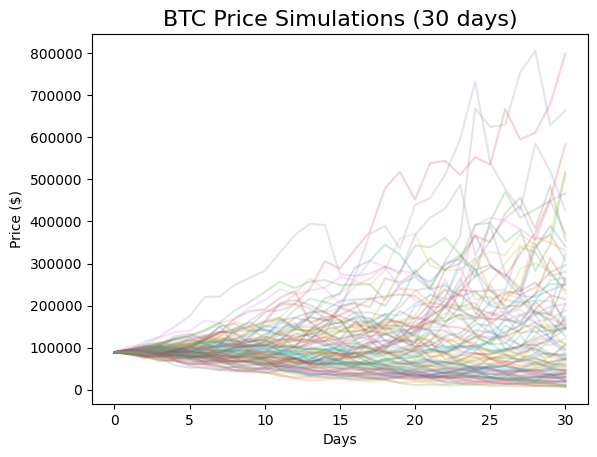

In [14]:
# Plot all simulations
gbm_simulations_df = pd.DataFrame(np.transpose(gbm_simulations))

ax = gbm_simulations_df.plot(alpha=0.2, legend=False)
ax.set_title('BTC Price Simulations (30 days)', fontsize=16)
ax.set_xlabel('Days')
ax.set_ylabel('Price ($)');

The y-axis has a wide range because some extreme values are possible given Bitcoin's high volatility.

## FRED Example: GDP Data

Let's pull another common series - U.S. GDP. The series code is `GDP`.

In [ ]:
gdp = fred.get_series('GDP', observation_start='2010-01-01', observation_end='2023-01-27')
gdp = gdp.to_frame(name='GDP')
gdp.head()

You can browse available series on the [FRED website](https://fred.stlouisfed.org/) and use their series codes with `fred.get_series()`. Check the [fredapi documentation](https://github.com/mortada/fredapi) for more options, like searching for series by keyword.